# Word-Level LSTM Language Model Trained on *Moby-Dick*

## Project Overview

This project trains a word-level LSTM language model on Herman Melville's *Moby-Dick* and uses it to generate new text in the novel's style. The model is evaluated against classical n-gram baselines using perplexity on held-out chapters. Three decoding strategies (greedy, temperature sampling, and top-k sampling) are compared on how diverse and repetitive their output is.

**Tools:** Python, PyTorch (CUDA), NumPy, pandas, matplotlib, seaborn.

## Objective

Build a next-word prediction model that measurably beats n-gram baselines on unseen chapters, and show how the choice of decoding strategy changes the generated text.

## Dataset

| Property | Value |
|---|---|
| Text | *Moby-Dick; or, The Whale*, Herman Melville (1851) |
| Source | [Project Gutenberg eBook #2701](https://www.gutenberg.org/ebooks/2701) |
| File | `data/melville-moby_dick.txt` (about 1.2 MB, 135 chapters plus an epilogue) |
| License | Public domain in the United States |

## Setup and Imports

In [ ]:
import math
import re
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

RANDOM_SEED = 42
DATA_PATH = Path("data") / "melville-moby_dick.txt"
MIN_WORD_COUNT = 3        # rarer training words become <unk>
SEQ_LEN = 64
BATCH_SIZE = 64
MAX_EPOCHS = 40
PATIENCE = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")
print(f"Device: {device}")

Device: cuda


## Data Preparation

### Splitting by chapter

Splitting a sliding window of tokens at random would put almost identical sequences into training and test, which inflates the scores. Instead, whole chapters are assigned to splits:

- Every chapter whose number ends in **8** goes to validation.
- Every chapter whose number ends in **9** goes to test.
- All other chapters, including the epilogue, are used for training.

Interleaving the held-out chapters keeps all three splits spread across the whole novel.

In [ ]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Expected the novel at {DATA_PATH.resolve()}. See the Dataset section.")

raw_text = DATA_PATH.read_text(encoding="utf-8")
chapter_texts = re.split(r"^CHAPTER (\d+)\s*$", raw_text, flags=re.MULTILINE)[1:]
chapters = {int(number): body for number, body in zip(chapter_texts[::2], chapter_texts[1::2])}

# The epilogue follows the last chapter in the same file
last = max(chapters)
chapters[last], _, epilogue = chapters[last].partition("Epilogue")
chapters[last + 1] = epilogue


def split_for_chapter(number):
    return {8: "validation", 9: "test"}.get(number % 10, "train")


print(f"Chapters (including epilogue): {len(chapters)}")
print(pd.Series([split_for_chapter(n) for n in chapters]).value_counts().to_string())

Chapters (including epilogue): 136
train         110
validation     13
test           13


### Tokenization and vocabulary

Text is lowercased and split into words (keeping internal apostrophes, as in *whale's*) and five punctuation marks (`. , ; ! ?`). Keeping sentence punctuation lets the model learn sentence boundaries, which makes the generated text easier to read.

The vocabulary is built from the **training chapters only**. Words that appear fewer than three times become `<unk>`, so the model sees an unknown token during training and can handle new words in held-out chapters.

In [ ]:
TOKEN_PATTERN = re.compile(r"[a-z]+(?:'[a-z]+)?|[.,;!?]")


def tokenize(text):
    lines = text.strip().splitlines()
    body = "\n".join(lines[1:]) if lines else ""     # first line is the chapter title
    return TOKEN_PATTERN.findall(body.lower())


split_tokens = {"train": [], "validation": [], "test": []}
for number in sorted(chapters):
    split_tokens[split_for_chapter(number)].extend(tokenize(chapters[number]))

word_counts = Counter(split_tokens["train"])
vocabulary = ["<unk>"] + sorted(w for w, c in word_counts.items() if c >= MIN_WORD_COUNT)
word_to_id = {w: i for i, w in enumerate(vocabulary)}
UNK_ID, VOCAB_SIZE = 0, len(vocabulary)

split_ids = {name: np.array([word_to_id.get(t, UNK_ID) for t in tokens], dtype=np.int64)
             for name, tokens in split_tokens.items()}

pd.DataFrame({
    "Tokens": {name: len(ids) for name, ids in split_ids.items()},
    "<unk> rate": {name: (ids == UNK_ID).mean() for name, ids in split_ids.items()},
}).style.format({"Tokens": "{:,}", "<unk> rate": "{:.2%}"})

,Tokens,rate
train,"203,326",6.09%
validation,"21,020",8.14%
test,"20,354",9.17%


In [ ]:
print(f"Vocabulary size: {VOCAB_SIZE:,} (out of {len(word_counts):,} distinct training words)")
print("Sample tokens:", " ".join(split_tokens["train"][:40]))

Vocabulary size: 5,907 (out of 15,673 distinct training words)
Sample tokens: call me ishmael . some years ago never mind how long precisely having little or no money in my purse , and nothing particular to interest me on shore , i thought i would sail about a little and see


## Exploratory Analysis

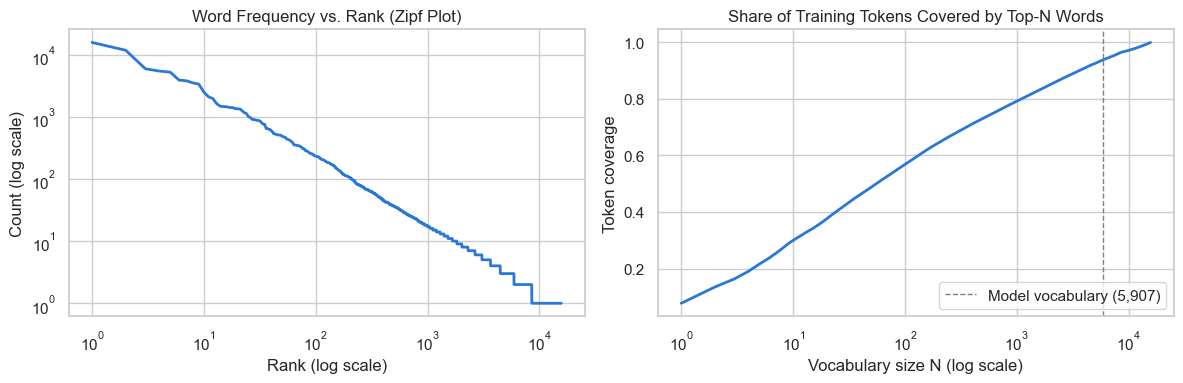

Most frequent tokens: ,, the, ., of, and, a, to, in, ;, that, his, it, i, but, he, as, with, was, is, !


In [ ]:
frequency = pd.Series(word_counts).sort_values(ascending=False)
coverage = frequency.cumsum() / frequency.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].loglog(np.arange(1, len(frequency) + 1), frequency.values, color="#2a78d6", linewidth=2)
axes[0].set_title("Word Frequency vs. Rank (Zipf Plot)")
axes[0].set_xlabel("Rank (log scale)")
axes[0].set_ylabel("Count (log scale)")

axes[1].plot(np.arange(1, len(coverage) + 1), coverage.values, color="#2a78d6", linewidth=2)
axes[1].axvline(VOCAB_SIZE, color="gray", linestyle="--", linewidth=1, label=f"Model vocabulary ({VOCAB_SIZE:,})")
axes[1].set_xscale("log")
axes[1].set_title("Share of Training Tokens Covered by Top-N Words")
axes[1].set_xlabel("Vocabulary size N (log scale)")
axes[1].set_ylabel("Token coverage")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Most frequent tokens:", ", ".join(frequency.index[:20]))

## Model Development

### Baselines: interpolated n-gram models

Each n-gram baseline mixes trigram, bigram, and unigram probabilities with weights λ (linear interpolation). The weights are chosen on the validation chapters. Interpolation ensures that a word sequence never seen in training still gets a non-zero probability.

In [ ]:
class InterpolatedNgram:
    def __init__(self, ids):
        self.unigram = np.bincount(ids, minlength=VOCAB_SIZE) + 1.0     # add-one on unigrams only
        self.unigram /= self.unigram.sum()
        self.bigram = Counter(zip(ids[:-1], ids[1:]))
        self.trigram = Counter(zip(ids[:-2], ids[1:-1], ids[2:]))
        self.context1 = Counter(ids[:-1])
        self.context2 = Counter(zip(ids[:-2], ids[1:-1]))

    def component_probs(self, ids):
        """Unigram, bigram, and trigram probabilities for every token from position 2 on."""
        w2, w1, w = ids[:-2], ids[1:-1], ids[2:]
        p1 = self.unigram[w]
        p2 = np.array([self.bigram[(a, b)] / self.context1[a] if self.context1[a] else 0.0 for a, b in zip(w1, w)])
        p3 = np.array([self.trigram[(a, b, c)] / self.context2[(a, b)] if self.context2[(a, b)] else 0.0
                       for a, b, c in zip(w2, w1, w)])
        return p1, p2, p3

    @staticmethod
    def perplexity(components, weights):
        mixed = sum(weight * p for weight, p in zip(weights, components))
        return float(np.exp(-np.log(mixed).mean()))


ngram = InterpolatedNgram(split_ids["train"])
val_components = ngram.component_probs(split_ids["validation"])
test_components = ngram.component_probs(split_ids["test"])

weight_grid = [(l1, l2, round(1 - l1 - l2, 2)) for l1 in np.arange(0.05, 1.0, 0.05)
               for l2 in np.arange(0.0, 1.0 - l1 + 1e-9, 0.05)]
best_weights = {
    "Unigram": (1.0, 0.0, 0.0),
    "Bigram (interpolated)": min([(l1, 1 - l1, 0.0) for l1 in np.arange(0.05, 1.0, 0.05)],
                                 key=lambda w: ngram.perplexity(val_components, w)),
    "Trigram (interpolated)": min(weight_grid, key=lambda w: ngram.perplexity(val_components, w)),
}
baseline_table = pd.DataFrame({
    name: {"λ (uni, bi, tri)": tuple(round(x, 2) for x in weights),
           "Validation perplexity": ngram.perplexity(val_components, weights),
           "Test perplexity": ngram.perplexity(test_components, weights)}
    for name, weights in best_weights.items()
}).T
baseline_table

,"λ (uni, bi, tri)",Validation perplexity,Test perplexity
Unigram,"(1.0, 0.0, 0.0)",343.799148,312.505736
Bigram (interpolated),"(0.4, 0.6, 0.0)",182.909533,172.832359
Trigram (interpolated),"(0.4, 0.5, 0.1)",177.400779,168.9938


### LSTM language model

The network embeds each word, passes the sequence through a 2-layer LSTM, and predicts the next word at **every** position. This is much more data-efficient than predicting only the last word of each window, which is how the original version of this project was set up.

Training details:

- The training text is cut into 64 parallel streams. The model reads them in 64-token segments and carries the hidden state from one segment to the next (truncated backpropagation through time), so it can use context beyond a single segment.
- **Regularization**: dropout on embeddings and between layers, plus weight tying, where the input embedding and the output layer share one matrix. With only about 170,000 training tokens, regularization matters more than model size.
- **Early stopping**: training stops once validation perplexity has not improved for 4 epochs, and the best checkpoint is restored. The learning rate is halved whenever validation perplexity stalls.

In [ ]:
class WordLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=400, n_layers=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(hidden_size, hidden_size, n_layers, batch_first=True, dropout=dropout)
        self.output = nn.Linear(hidden_size, vocab_size)
        self.output.weight = self.embedding.weight      # weight tying

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(self.dropout(self.embedding(x)), hidden)
        return self.output(self.dropout(out)), hidden


def to_streams(ids, n_streams):
    """Reshape a token sequence into n_streams contiguous rows."""
    usable = len(ids) // n_streams * n_streams
    return torch.from_numpy(ids[:usable]).view(n_streams, -1).to(device)


def detach(hidden):
    return tuple(h.detach() for h in hidden)


def run_epoch(model, streams, optimizer=None):
    """One pass over the streams; trains if an optimizer is given. Returns mean loss in nats."""
    training = optimizer is not None
    model.train(training)
    hidden, total_loss, total_tokens = None, 0.0, 0
    with torch.set_grad_enabled(training):
        for start in range(0, streams.shape[1] - 1, SEQ_LEN):
            x = streams[:, start:start + SEQ_LEN]
            y = streams[:, start + 1:start + 1 + SEQ_LEN]
            x = x[:, :y.shape[1]]
            logits, hidden = model(x, hidden)
            hidden = detach(hidden)
            loss = nn.functional.cross_entropy(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                optimizer.step()
            total_loss += loss.item() * y.numel()
            total_tokens += y.numel()
    return total_loss / total_tokens


train_streams = to_streams(split_ids["train"], BATCH_SIZE)
val_streams = to_streams(split_ids["validation"], 8)
test_streams = to_streams(split_ids["test"], 8)

model = WordLSTM(VOCAB_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=1)

history, best_val, best_state, epochs_without_improvement = [], float("inf"), None, 0
start_time = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_epoch(model, train_streams, optimizer)
    val_loss = run_epoch(model, val_streams)
    scheduler.step(val_loss)
    history.append({"epoch": epoch, "train_ppl": math.exp(train_loss), "val_ppl": math.exp(val_loss)})
    if val_loss < best_val:
        best_val, epochs_without_improvement = val_loss, 0
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            break

model.load_state_dict(best_state)
history = pd.DataFrame(history)
best_epoch = int(history.loc[history["val_ppl"].idxmin(), "epoch"])
print(f"Stopped after {len(history)} epochs ({time.perf_counter() - start_time:.0f} s). "
      f"Best validation perplexity {math.exp(best_val):.1f} at epoch {best_epoch}.")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Stopped after 34 epochs (39 s). Best validation perplexity 120.7 at epoch 30.
Parameters: 4,935,107


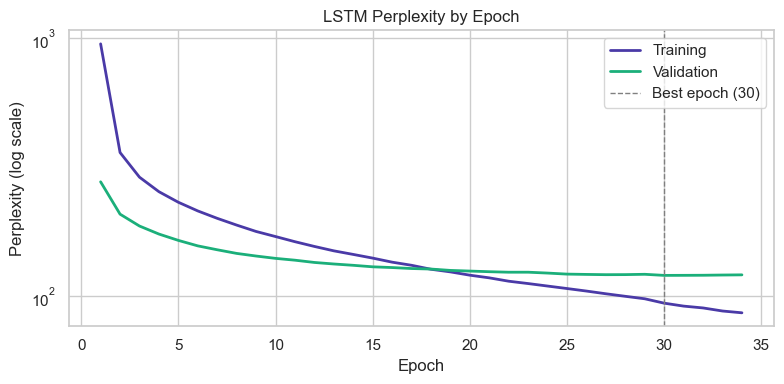

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history["epoch"], history["train_ppl"], color="#4a3aa7", linewidth=2, label="Training")
ax.plot(history["epoch"], history["val_ppl"], color="#1baf7a", linewidth=2, label="Validation")
ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=1, label=f"Best epoch ({best_epoch})")
ax.set_yscale("log")
ax.set_title("LSTM Perplexity by Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Perplexity (log scale)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Model Evaluation

Perplexity is the exponential of the average negative log-likelihood per token. One way to read it: a perplexity of 100 means the model is as uncertain as if it were choosing uniformly among 100 words at each step. Next-word top-1 and top-5 accuracy give a more intuitive view of the same comparison.

In [ ]:
@torch.no_grad()
def lstm_token_outputs(ids):
    """Per-token log-probabilities and top-5 hits for a held-out split, carrying state across segments."""
    model.eval()
    x = torch.from_numpy(ids[:-1]).unsqueeze(0).to(device)
    y = torch.from_numpy(ids[1:]).unsqueeze(0).to(device)
    hidden, log_probs, top5 = None, [], []
    for start in range(0, x.shape[1], SEQ_LEN):
        logits, hidden = model(x[:, start:start + SEQ_LEN], hidden)
        lp = torch.log_softmax(logits[0], dim=-1)
        target = y[0, start:start + SEQ_LEN]
        log_probs.append(lp.gather(1, target[:, None]).squeeze(1))
        top5.append((lp.topk(5, dim=-1).indices == target[:, None]))
    return torch.cat(log_probs).cpu().numpy(), torch.cat(top5).cpu().numpy()


test_log_probs, test_top5 = lstm_token_outputs(split_ids["test"])
# Align with the n-gram scores, which start at the third token
lstm_log_probs, lstm_top5 = test_log_probs[1:], test_top5[1:]

tri_weights = best_weights["Trigram (interpolated)"]
trigram_probs = sum(w * p for w, p in zip(tri_weights, test_components))


def ngram_topk_hits(ids, k=5):
    """Top-k next-word accuracy for the interpolated trigram, using its full predictive distribution."""
    hits = np.zeros((len(ids) - 2, k), dtype=bool)
    l1, l2, l3 = tri_weights
    for i, (a, b, target) in enumerate(zip(ids[:-2], ids[1:-1], ids[2:])):
        scores = l1 * ngram.unigram.copy()
        if ngram.context1[b]:
            for (_, nxt), count in bigram_followers.get(b, {}).items():
                scores[nxt] += l2 * count / ngram.context1[b]
        if ngram.context2[(a, b)]:
            for nxt, count in trigram_followers.get((a, b), {}).items():
                scores[nxt] += l3 * count / ngram.context2[(a, b)]
        top = np.argpartition(-scores, k)[:k]
        top = top[np.argsort(-scores[top])]
        hits[i] = top == target
    return hits


bigram_followers, trigram_followers = {}, {}
for (a, b), count in ngram.bigram.items():
    bigram_followers.setdefault(a, {})[(a, b)] = count
for (a, b, c), count in ngram.trigram.items():
    trigram_followers.setdefault((a, b), {})[c] = count
trigram_top5 = ngram_topk_hits(split_ids["test"])

evaluation = pd.DataFrame({
    "Unigram": {"Test perplexity": baseline_table.loc["Unigram", "Test perplexity"]},
    "Bigram (interpolated)": {"Test perplexity": baseline_table.loc["Bigram (interpolated)", "Test perplexity"]},
    "Trigram (interpolated)": {"Test perplexity": baseline_table.loc["Trigram (interpolated)", "Test perplexity"],
                               "Top-1 accuracy": trigram_top5[:, 0].mean(), "Top-5 accuracy": trigram_top5.any(axis=1).mean()},
    "LSTM": {"Test perplexity": float(np.exp(-lstm_log_probs.mean())),
             "Top-1 accuracy": lstm_top5[:, 0].mean(), "Top-5 accuracy": lstm_top5.any(axis=1).mean()},
}).T
evaluation.astype(float).round(3)

,Test perplexity,Top-1 accuracy,Top-5 accuracy
Unigram,312.506,NaN,NaN
Bigram (interpolated),172.832,NaN,NaN
Trigram (interpolated),168.994,0.180,0.376
LSTM,115.609,0.201,0.426


### Generated text and decoding strategies

The same trained model can produce very different text depending on how the next word is chosen:

- **Greedy**: always pick the most likely word.
- **Temperature sampling**: sample from the softmax distribution after dividing the logits by *T*.
- **Top-k sampling**: sample only among the *k* most likely words.

`<unk>` is never sampled. Diversity is measured with **distinct-2**, the share of unique bigrams in the generated text, and **repetition**, the share of 4-grams that occur more than once in the same sample.

In [ ]:
@torch.no_grad()
def generate(prompt, n_words=60, strategy="temperature", temperature=0.8, top_k=40, seed=RANDOM_SEED):
    model.eval()
    generator = torch.Generator(device=device).manual_seed(seed)
    ids = [word_to_id.get(t, UNK_ID) for t in TOKEN_PATTERN.findall(prompt.lower())]
    logits, hidden = model(torch.tensor([ids], device=device))
    output = []
    for _ in range(n_words):
        next_logits = logits[0, -1].clone()
        next_logits[UNK_ID] = -float("inf")
        if strategy == "greedy":
            next_id = int(next_logits.argmax())
        else:
            if strategy == "top_k":
                threshold = next_logits.topk(top_k).values[-1]
                next_logits[next_logits < threshold] = -float("inf")
            probs = torch.softmax(next_logits / temperature, dim=-1)
            next_id = int(torch.multinomial(probs, 1, generator=generator))
        output.append(vocabulary[next_id])
        logits, hidden = model(torch.tensor([[next_id]], device=device), hidden)
    text = " ".join(output)
    return re.sub(r" ([.,;!?])", r"\1", text)


def diversity_metrics(text):
    tokens = TOKEN_PATTERN.findall(text)
    bigrams = list(zip(tokens, tokens[1:]))
    fourgrams = Counter(zip(tokens, tokens[1:], tokens[2:], tokens[3:]))
    repeated = sum(c for c in fourgrams.values() if c > 1)
    return len(set(bigrams)) / max(len(bigrams), 1), repeated / max(sum(fourgrams.values()), 1)


PROMPT = "the whale rose from the sea and"
STRATEGIES = {
    "Greedy": dict(strategy="greedy"),
    "Temperature 0.7": dict(strategy="temperature", temperature=0.7),
    "Temperature 1.0": dict(strategy="temperature", temperature=1.0),
    "Top-k (k=40, T=0.9)": dict(strategy="top_k", top_k=40, temperature=0.9),
}
for name, settings in STRATEGIES.items():
    print(f"--- {name} ---\n{PROMPT} {generate(PROMPT, **settings)}\n")

--- Greedy ---
the whale rose from the sea and the sea. the ship was now to be seen, and the other, and the whale, the whale was now to be seen; and the ship was now to be seen, and the other, and the whale, and the other, and the whale, the whale was now to be seen;



--- Temperature 0.7 ---
the whale rose from the sea and the ship's deck to keep myself round the whale, and the ship, and the twenty thousand hours, and the line, and the half way, and in the subtle rampart of our dish, the crisp, was completely up as the dark, and the best line of that complete body was heard, that

--- Temperature 1.0 ---
the whale rose from the sea and her night on the deck, but to be flung you and turn to the sea. it was his eyes; he must be attentively that a coffin looked in him, and made our dish; and through his entangled on exhaled power, that a creature, or so ran at intervals, he would not besides

--- Top-k (k=40, T=0.9) ---
the whale rose from the sea and her night on the deck, and to be sure you saw the same with the whale; and so, so as to be found as a sailor. in the present case, the carpenter was now a day, they seemed as yet that a creature, or so much more strangely than the same way.



In [ ]:
diversity_rows = []
for name, settings in STRATEGIES.items():
    samples = [generate(PROMPT, n_words=100, seed=s, **settings) for s in range(20)]
    metrics = np.array([diversity_metrics(s) for s in samples])
    diversity_rows.append({"Strategy": name, "Distinct-2": metrics[:, 0].mean(), "Repeated 4-grams": metrics[:, 1].mean()})

pd.DataFrame(diversity_rows).set_index("Strategy").round(3)

,Distinct-2,Repeated 4-grams
Strategy,,
Greedy,0.202,0.948
Temperature 0.7,0.889,0.004
Temperature 1.0,0.969,0.001
"Top-k (k=40, T=0.9)",0.921,0.002


## Error Analysis

### Where does the LSTM beat the trigram model?

Comparing per-token log-likelihoods on the test chapters shows which words gain the most from the LSTM's longer context. Test tokens are grouped by how often the target word appears in training.

In [ ]:
test_targets = split_ids["test"][2:]
train_frequency = np.bincount(split_ids["train"], minlength=VOCAB_SIZE)[test_targets]
buckets = pd.cut(train_frequency, bins=[0, 2, 10, 100, 1000, np.inf],
                 labels=["<unk>/rare", "3-10", "11-100", "101-1,000", ">1,000"], include_lowest=True)
buckets = np.where(test_targets == UNK_ID, "<unk>/rare", buckets.astype(str))

token_comparison = pd.DataFrame({
    "bucket": buckets,
    "LSTM loss": -lstm_log_probs,
    "Trigram loss": -np.log(trigram_probs),
})
bucket_order = ["<unk>/rare", "3-10", "11-100", "101-1,000", ">1,000"]
by_bucket = token_comparison.groupby("bucket").agg(
    tokens=("LSTM loss", "size"), lstm_ppl=("LSTM loss", lambda x: np.exp(x.mean())),
    trigram_ppl=("Trigram loss", lambda x: np.exp(x.mean())),
).reindex(bucket_order)
by_bucket["LSTM improvement"] = 1 - by_bucket["lstm_ppl"] / by_bucket["trigram_ppl"]
by_bucket.round(2)

,tokens,lstm_ppl,trigram_ppl,LSTM improvement
bucket,,,,
<unk>/rare,1865,12.450000,14.52,0.14
3-10,1706,23250.740234,29656.52,0.22
11-100,3482,2199.330078,3078.79,0.29
"101-1,000",4935,154.539993,242.73,0.36
">1,000",8364,15.920000,24.56,0.35


In [ ]:
token_comparison["word"] = np.array(vocabulary)[test_targets]
token_comparison["gain"] = token_comparison["Trigram loss"] - token_comparison["LSTM loss"]
word_gain = (token_comparison[token_comparison["word"] != "<unk>"]
             .groupby("word").agg(occurrences=("gain", "size"), mean_gain_nats=("gain", "mean"))
             .query("occurrences >= 15"))
pd.DataFrame({
    "LSTM much better": word_gain.nlargest(10, "mean_gain_nats").index,
    "Trigram better": word_gain.nsmallest(10, "mean_gain_nats").index,
})

,LSTM much better,Trigram better
0,thee,fish
1,thy,most
2,moment,fast
3,than,shipmates
4,thing,round
5,?,who
6,sir,lord
7,were,those
8,goes,almost
9,go,after


## Key Findings

| Model (13 held-out chapters) | Test perplexity | Top-1 accuracy | Top-5 accuracy |
|---|---|---|---|
| Unigram | 312.5 | – | – |
| Bigram (interpolated) | 172.8 | – | – |
| Trigram (interpolated) | 169.0 | 0.180 | 0.376 |
| **LSTM (2 layers, 400 units, weight tying)** | **115.6** | **0.201** | **0.426** |

- **The LSTM reduces perplexity by 32% compared with the best n-gram model** on chapters it never saw. Its top-5 next-word accuracy is 42.6%.
- **Trigrams add almost nothing over bigrams** (169.0 vs. 172.8). The tuned interpolation gives trigrams only 10% of the weight, because most three-word sequences in held-out chapters never occur in 170,000 training tokens. The LSTM avoids this sparsity by sharing information between similar contexts through embeddings.
- **Regularization and early stopping matter on a corpus this small.** Training perplexity keeps falling, but validation perplexity flattens after about 20 epochs. The best checkpoint (epoch 30) was restored automatically. The original Keras version had no held-out monitoring, and its validation loss rose from the first epoch.
- **The LSTM helps most on common words** (about 35% lower perplexity for words seen more than 100 times) and least on rare ones (14%). The words it gains most on, *thee*, *thy*, and *sir*, depend on recognizing dialogue and archaic speech, which requires context longer than two words.
- **The decoding strategy determines output quality as much as the model does.** Greedy decoding falls into loops ("the whale was now to be seen; and the ship was now to be seen..."), with 95% of its 4-grams repeated. Temperature and top-k sampling remove the repetition (≤ 0.4% repeated 4-grams). In the samples shown, top-k at T = 0.9 reads most naturally, while temperature 1.0 is the most diverse but least grammatical.

## Limitations

- About 170,000 training tokens is a very small corpus for a neural language model. Generated text is locally fluent but loses coherence beyond a sentence or two.
- Perplexity depends on the vocabulary. Merging rare words into `<unk>` makes prediction easier, so these numbers are only comparable to models that use the same vocabulary.
- The diversity metrics measure variety, not quality. Temperature 1.0 is the most diverse setting, but it also produces the most ungrammatical output.

## Next Steps

- Fine-tune a small pretrained transformer (for example, GPT-2 small) on the same chapters and compare perplexity on a shared tokenization.
- Train on several 19th-century novels to reduce overfitting, then fine-tune on *Moby-Dick* for style.
- Add nucleus (top-p) sampling and a human or model-based fluency rating alongside the diversity metrics.

## Attribution

- Text: Herman Melville, *Moby-Dick* (1851), via Project Gutenberg (public domain in the U.S.)